In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


**LOAD THE DATA**

In [41]:
df_us= pd.read_csv('../../data/processed/us_df.csv', index_col=0)
df_us.head()

,ReportDate,ReportTitle,Attribute,ReliabilityProjection,Commodity,Region,MarketYear,ProjEstFlag,AnnualQuarterFlag,Value,Unit,ReleaseDate,ReleaseTime,ForecastYear,ForecastMonth
WasdeNumber,,,,,,,,,,,,,,,
481,April 2010,U.S. Cotton Supply and Use,Avg. farm price,NaN,Cotton,United States,2007/08,NaN,Annual,59.30,Million 480 Pound Bales,2010-04-09,08:30:00.0000000,2010,4
481,April 2010,U.S. Cotton Supply and Use,Beginning stocks,NaN,Cotton,United States,2007/08,NaN,Annual,9.48,Million 480 Pound Bales,2010-04-09,08:30:00.0000000,2010,4
481,April 2010,U.S. Cotton Supply and Use,Domestic use,NaN,Cotton,United States,2007/08,NaN,Annual,4.59,Million 480 Pound Bales,2010-04-09,08:30:00.0000000,2010,4
481,April 2010,U.S. Cotton Supply and Use,Ending stocks,NaN,Cotton,United States,2007/08,NaN,Annual,10.04,Million 480 Pound Bales,2010-04-09,08:30:00.0000000,2010,4
481,April 2010,U.S. Cotton Supply and Use,"Exports, total",NaN,Cotton,United States,2007/08,NaN,Annual,13.65,Million 480 Pound Bales,2010-04-09,08:30:00.0000000,2010,4


# **INITIAL CLEANING**

In [42]:
# Investigate reliability projection
df_us["ReliabilityProjection"].value_counts(dropna=False)

ReliabilityProjection
NaN    273893
Name: count, dtype: int64

In [43]:
df_us.groupby("ReliabilityProjection")["ReportTitle"].value_counts()

Series([], Name: count, dtype: int64)

In [44]:
df_us["ReportTitle"].value_counts()

ReportTitle
U.S. Meats Supply and Use                                       31752
U.S. Sorghum, Barley, and Oats Supply and Use                   24171
U.S. Rice Supply and Use                                        21476
U.S. Soybeans and Products Supply and Use (Domestic Measure)    19524
U.S. Quarterly Animal Product Production                        18711
U.S. Feed Grain and Corn Supply and Use                         17099
U.S. Wheat by Class: Supply and Use                             16068
U.S. Quarterly Prices for Animal Products                       15937
U.S. Milk Supply and Use                                        14008
U.S. Sugar Supply and Use                                       12438
U.S. Wheat Supply and Use                                        9152
World and U.S Supply and Use for Grains                          9120
World and U.S. Supply and Use for Oilseeds                       8505
U.S. Cotton Supply and Use                                       7484
U.S. Egg

In [45]:
df_us["ReportTitle"].nunique()

26

In [46]:
sorted(df_us["ReportTitle"].unique())

['U.S. Cotton Supply and Use',
 'U.S. Dairy Prices',
 'U.S. Egg Supply and Use',
 'U.S. Feed Grain and Corn Supply and Use',
 'U.S. Meats Supply and Use',
 'U.S. Milk Supply and Use',
 'U.S. Quarterly Animal Product Production',
 'U.S. Quarterly Prices for Animal Products',
 'U.S. Rice Supply and Use',
 'U.S. Sorghum, Barley, and Oats Supply and Use',
 'U.S. Soybeans and Products Supply and Use (Domestic Measure)',
 'U.S. Sugar Supply and Use',
 'U.S. Wheat Supply and Use',
 'U.S. Wheat by Class: Supply and Use',
 'World Coarse Grain Supply and Use',
 'World Corn Supply and Use',
 'World Cotton Supply and Use',
 'World Rice Supply and Use  (Milled Basis)',
 'World Soybean Meal Supply and Use',
 'World Soybean Oil Supply and Use',
 'World Soybean Supply and Use',
 'World Wheat Supply and Use',
 'World and U.S Supply and Use for Grains',
 'World and U.S. Supply and Use for Cotton',
 'World and U.S. Supply and Use for Grains',
 'World and U.S. Supply and Use for Oilseeds']

In [47]:
# Filtering out reliability projection
df_us = df_us[
    ~df_us["ReportTitle"].str.contains("Reliability", na=False)
]

In [48]:
us_reports = df_us["ReportTitle"].value_counts()
us_reports

ReportTitle
U.S. Meats Supply and Use                                       31752
U.S. Sorghum, Barley, and Oats Supply and Use                   24171
U.S. Rice Supply and Use                                        21476
U.S. Soybeans and Products Supply and Use (Domestic Measure)    19524
U.S. Quarterly Animal Product Production                        18711
U.S. Feed Grain and Corn Supply and Use                         17099
U.S. Wheat by Class: Supply and Use                             16068
U.S. Quarterly Prices for Animal Products                       15937
U.S. Milk Supply and Use                                        14008
U.S. Sugar Supply and Use                                       12438
U.S. Wheat Supply and Use                                        9152
World and U.S Supply and Use for Grains                          9120
World and U.S. Supply and Use for Oilseeds                       8505
U.S. Cotton Supply and Use                                       7484
U.S. Egg

In [49]:
us_reports[us_reports.index.str.startswith("U.S.")]

ReportTitle
U.S. Meats Supply and Use                                       31752
U.S. Sorghum, Barley, and Oats Supply and Use                   24171
U.S. Rice Supply and Use                                        21476
U.S. Soybeans and Products Supply and Use (Domestic Measure)    19524
U.S. Quarterly Animal Product Production                        18711
U.S. Feed Grain and Corn Supply and Use                         17099
U.S. Wheat by Class: Supply and Use                             16068
U.S. Quarterly Prices for Animal Products                       15937
U.S. Milk Supply and Use                                        14008
U.S. Sugar Supply and Use                                       12438
U.S. Wheat Supply and Use                                        9152
U.S. Cotton Supply and Use                                       7484
U.S. Egg Supply and Use                                          6804
U.S. Dairy Prices                                                6538
Name: co

In [50]:
df_us["ReportTitle"].str.contains("Reliability", na=False).sum()

np.int64(0)

The original dataset contains both standard WASDE reports and reliability reports. Reliability reports summarize historical forecast accuracy (e.g., RMSE, confidence intervals, forecast bias) rather than commodity supply and demand observations. Since the objective of this project is to analyze and forecast commodity data, these reports were removed from the dataset.

In [51]:
# Check data types
df_us.dtypes

ReportDate                   str
ReportTitle                  str
Attribute                    str
ReliabilityProjection    float64
Commodity                    str
Region                       str
MarketYear                   str
ProjEstFlag                  str
AnnualQuarterFlag            str
Value                    float64
Unit                         str
ReleaseDate                  str
ReleaseTime                  str
ForecastYear               int64
ForecastMonth              int64
dtype: object

In [52]:
# Convert releasedate to datetime
df_us["ReleaseDate"] = pd.to_datetime(
    df_us["ReleaseDate"],
    format="mixed"
)
df_us["ReleaseDate"].dtype

dtype('<M8[us]')

In [53]:
df_us["Value"] = pd.to_numeric(df_us["Value"], errors="coerce")

In [54]:
df_us.info()

<class 'pandas.DataFrame'>
Index: 273893 entries, 481 to 670
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   ReportDate             273893 non-null  str           
 1   ReportTitle            273893 non-null  str           
 2   Attribute              273893 non-null  str           
 3   ReliabilityProjection  0 non-null       float64       
 4   Commodity              273893 non-null  str           
 5   Region                 273893 non-null  str           
 6   MarketYear             273893 non-null  str           
 7   ProjEstFlag            166871 non-null  str           
 8   AnnualQuarterFlag      273893 non-null  str           
 9   Value                  273183 non-null  float64       
 10  Unit                   273893 non-null  str           
 11  ReleaseDate            273893 non-null  datetime64[us]
 12  ReleaseTime            273893 non-null  str           
 13  F

Investigating the rows

In [55]:
df_us["Commodity"].value_counts()

Commodity
Wheat               15956
Cotton              14288
Corn                13157
Sugar               12438
Oilseed, Soybean    12014
                    ...  
PORK                   24
TOTAL POULTRY          24
TOTAL RED MEAT         24
TURKEY                 24
Choice steers          15
Name: count, Length: 61, dtype: int64

In [56]:
df_us["Attribute"].value_counts()

Attribute
Production             38742
Ending Stocks          21497
Imports                18309
Exports                17937
Beginning Stocks       15048
                       ...  
Beet sugar                 3
Cane sugar                 3
Other program              3
Stocks to use ratio        3
Total use                  3
Name: count, Length: 129, dtype: int64

In [57]:
df_us["Unit"].value_counts()

Unit
Million Pounds                52668
Million Bushels               52302
Million Metric Tons           52137
Billion Pounds                15319
Million Hundredweight         14297
1000 Short Tons, Raw Value    12438
Million Dozen                  8127
Dol./cwt                       7990
Million Acres                  6804
Million 480 Pound Bales        5783
Cents/lb.                      5298
Thousand Short Tons            4536
$/bu                           4116
Million 480-Pound Bales        3969
Dollars Per Cwt                3736
mil. acres                     3402
Million 480-lb. Bales          2835
Dollars Per Pound              2802
Cents/Doz.                     2649
$/cwt                          2076
Bushels                        1701
bushels/acre                   1701
Pounds                         1134
mil.                           1134
pounds/acre                    1134
number                          756
$/s.t.                          674
c/lb                   

This suggests that each commodity should have its own time series.

In [58]:
df_us["MarketYear"].value_counts().sort_index()

MarketYear
2007           38
2007/08       290
2008          565
2008/09      3812
2009         2158
2009/10      7836
2010         4396
2010/011      482
2010/11     11054
2011         6309
2011/012      389
2011/12     10866
2012         6175
2012/013      233
2012/13     10986
2013         6068
2013/014       70
2013/14     11065
2014         6018
2014/15     11406
2015         6159
2015/16     11334
2016         6125
2016/17     11050
2017         6054
2017/18     11010
2018         5994
2018/19     10976
2019         5775
2019/20     11160
2020         5572
2020/21     10898
2021         5462
2021/22     10880
2022         5393
2022/23     11180
2023         5352
2023/24     11462
2024         5030
2024/25      7964
2025         3524
2025/26      3740
2026         1583
Name: count, dtype: int64

# **Understanding the data**

In [59]:
# open market commodities
corn = df_us[
    df_us["ReportTitle"] == "U.S. Feed Grain and Corn Supply and Use"
]
soybeans = df_us[
    df_us["ReportTitle"] == "U.S. Soybeans and Products Supply and Use (Domestic Measure)"
]
cotton = df_us[
    df_us["ReportTitle"] == "U.S. Cotton Supply and Use"
]
wheat = df_us[
    df_us["ReportTitle"] == "U.S. Wheat Supply and Use"
]

In [60]:
cotton["Commodity"].value_counts()

Commodity
Cotton    7484
Name: count, dtype: int64

In [61]:
cotton["Attribute"].value_counts()


Attribute
Harvested                   567
Imports                     567
Planted                     567
Production                  567
Unaccounted                 567
Beginning Stocks            564
Domestic Use                564
Ending Stocks               564
Exports, Total              564
Supply, Total               564
Use, Total                  564
Yield per Harvested Acre    564
Avg. Farm Price             452
Avg. Farm Price - High      112
Avg. Farm Price - Low       112
Beginning stocks              3
Domestic use                  3
Ending stocks                 3
Exports, total                3
Supply, total                 3
Use, total                    3
Yield per harvested acre      3
Avg. farm price               2
Avg. farm price - High        1
Avg. farm price - Low         1
Name: count, dtype: int64

In [62]:
soybeans["Commodity"].value_counts()


Commodity
Oilseed, Soybean    8045
Oil, Soybean        6269
Meal, Soybean       5210
Name: count, dtype: int64

In [63]:
soybeans["Attribute"].value_counts()

Attribute
Exports                          1701
Imports                          1701
Production                       1701
Beginning Stocks                 1692
Supply, Total                    1692
Use, Total                       1692
Avg. Farm Price                  1374
Ending Stocks                    1128
Domestic Disappearance            984
Ending stocks                     573
Area Harvested                    567
Area Planted                      567
Crushings                         567
Residual                          567
Seed                              567
Yield per Harvested Acre          564
Food, Feed & other Industrial     510
Avg. Farm Price - High            318
Avg. Farm Price - Low             318
Biodiesel                         300
Biofuel                           174
Domestic                          150
For Methyl Ester                   36
Methyl Ester                       36
Beginning stocks                    9
Supply, total                       9
Us

# **EDA**

Designing a commodity EDA pipeline manually before defining the actual pipeline function for other commodities.

In [64]:
corn = df_us[
    df_us["ReportTitle"] == "U.S. Feed Grain and Corn Supply and Use"
]

In [65]:
corn_prod = corn[
    (corn["Commodity"] == "Corn") &
    (corn["Attribute"] == "Production")
].copy()

In [66]:
corn_prod.shape

(567, 15)

In [67]:
corn_prod.sort_values("ReleaseDate").head()

,ReportDate,ReportTitle,Attribute,ReliabilityProjection,Commodity,Region,MarketYear,ProjEstFlag,AnnualQuarterFlag,Value,Unit,ReleaseDate,ReleaseTime,ForecastYear,ForecastMonth
WasdeNumber,,,,,,,,,,,,,,,
481,April 2010,U.S. Feed Grain and Corn Supply and Use,Production,NaN,Corn,United States,2007/08,NaN,Annual,13038.0,Million Bushels,2010-04-09,08:30:00.0000000,2010,4
481,April 2010,U.S. Feed Grain and Corn Supply and Use,Production,NaN,Corn,United States,2008/09,Est.,Annual,12092.0,Million Bushels,2010-04-09,08:30:00.0000000,2010,4
481,April 2010,U.S. Feed Grain and Corn Supply and Use,Production,NaN,Corn,United States,2009/10,Proj.,Annual,13131.0,Million Bushels,2010-04-09,08:30:00.0000000,2010,4
482,May 2010,U.S. Feed Grain and Corn Supply and Use,Production,NaN,Corn,United States,2008/09,NaN,Annual,12092.0,Million Bushels,2010-05-11,08:30:00.0000000,2010,5
482,May 2010,U.S. Feed Grain and Corn Supply and Use,Production,NaN,Corn,United States,2009/10,Est.,Annual,13110.0,Million Bushels,2010-05-11,08:30:00.0000000,2010,5


Important Note: Release date is when the USDA published the forecast, Market year is the crop year the forecast refers to

In [68]:
corn_prod.info()

<class 'pandas.DataFrame'>
Index: 567 entries, 481 to 670
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ReportDate             567 non-null    str           
 1   ReportTitle            567 non-null    str           
 2   Attribute              567 non-null    str           
 3   ReliabilityProjection  0 non-null      float64       
 4   Commodity              567 non-null    str           
 5   Region                 567 non-null    str           
 6   MarketYear             567 non-null    str           
 7   ProjEstFlag            378 non-null    str           
 8   AnnualQuarterFlag      567 non-null    str           
 9   Value                  567 non-null    float64       
 10  Unit                   567 non-null    str           
 11  ReleaseDate            567 non-null    datetime64[us]
 12  ReleaseTime            567 non-null    str           
 13  ForecastYear       

In [69]:
corn_prod.describe(include="all")

,ReportDate,ReportTitle,Attribute,ReliabilityProjection,Commodity,Region,MarketYear,ProjEstFlag,AnnualQuarterFlag,Value,Unit,ReleaseDate,ReleaseTime,ForecastYear,ForecastMonth
count,567,567,567,0.0,567,567,567,378,567,567.000000,567,567,567,567.000000,567.000000
unique,189,1,1,NaN,1,1,19,2,1,NaN,1,NaN,3,NaN,NaN
top,April 2010,U.S. Feed Grain and Corn Supply and Use,Production,NaN,Corn,United States,2010/11,Est.,Annual,NaN,Million Bushels,NaN,12:00:00.0000000,NaN,NaN
freq,3,567,567,NaN,567,567,36,189,567,NaN,567,NaN,453,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13878.984127,NaN,2018-03-25 22:20:57.142857,NaN,2017.751323,6.460317
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10706.000000,NaN,2010-04-09 00:00:00,NaN,2010.000000,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13487.500000,NaN,2014-04-09 00:00:00,NaN,2014.000000,4.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14040.000000,NaN,2018-03-08 00:00:00,NaN,2018.000000,6.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14808.500000,NaN,2022-03-09 00:00:00,NaN,2022.000000,9.000000
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17021.000000,NaN,2026-04-09 00:00:00,NaN,2026.000000,12.000000


In [70]:
corn_prod = corn_prod.sort_values("ReleaseDate")

In [71]:
corn_prod[["ReleaseDate", "MarketYear", "Value"]].head(10)

,ReleaseDate,MarketYear,Value
WasdeNumber,,,
481,2010-04-09,2007/08,13038.0
481,2010-04-09,2008/09,12092.0
481,2010-04-09,2009/10,13131.0
482,2010-05-11,2008/09,12092.0
482,2010-05-11,2009/10,13110.0
482,2010-05-11,2010/11,13370.0
483,2010-06-10,2008/09,12092.0
483,2010-06-10,2009/10,13110.0
483,2010-06-10,2010/11,13370.0


In [72]:
corn_prod[["ReleaseDate", "MarketYear", "Value"]].tail(10)

,ReleaseDate,MarketYear,Value
WasdeNumber,,,
667,2026-01-12,2025/26,17021.0
668,2026-02-10,2024/25,14892.0
668,2026-02-10,2023/24,15341.0
668,2026-02-10,2025/26,17021.0
669,2026-03-10,2024/25,14892.0
669,2026-03-10,2023/24,15341.0
669,2026-03-10,2025/26,17021.0
670,2026-04-09,2024/25,14892.0
670,2026-04-09,2023/24,15341.0


In [73]:
# check for missing values
corn_prod.isna().sum()

ReportDate                 0
ReportTitle                0
Attribute                  0
ReliabilityProjection    567
Commodity                  0
Region                     0
MarketYear                 0
ProjEstFlag              189
AnnualQuarterFlag          0
Value                      0
Unit                       0
ReleaseDate                0
ReleaseTime                0
ForecastYear               0
ForecastMonth              0
dtype: int64

In [74]:
# Summary statistics
corn_prod["Value"].describe()

count      567.000000
mean     13878.984127
std       1222.675545
min      10706.000000
25%      13487.500000
50%      14040.000000
75%      14808.500000
max      17021.000000
Name: Value, dtype: float64

In [75]:
# median value
corn_prod["Value"].median()


np.float64(14040.0)

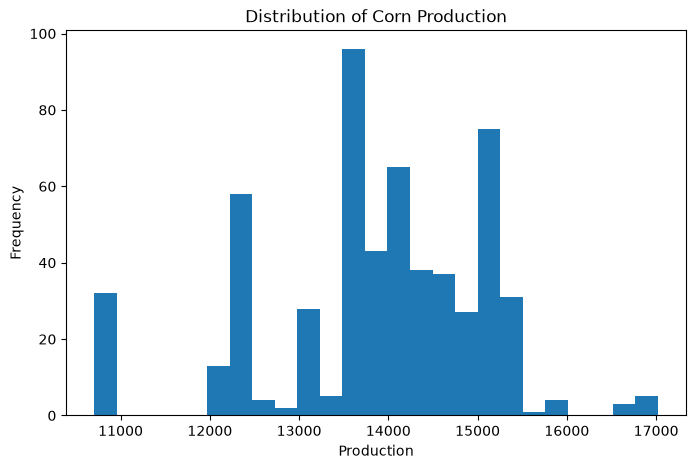

In [76]:
# Visualize the distribution
plt.figure(figsize=(8,5))
plt.hist(corn_prod["Value"], bins=25)
plt.title("Distribution of Corn Production")
plt.xlabel("Production")
plt.ylabel("Frequency")
plt.show()

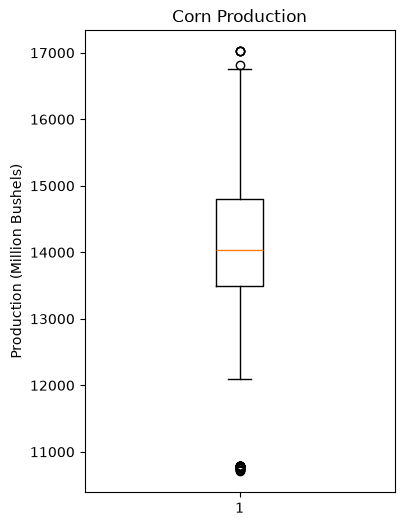

In [77]:
# Boxplot
plt.figure(figsize=(4,6))
plt.boxplot(corn_prod["Value"])
plt.title("Corn Production")
plt.ylabel("Production (Million Bushels)")
plt.show()

**TIME SERIES**

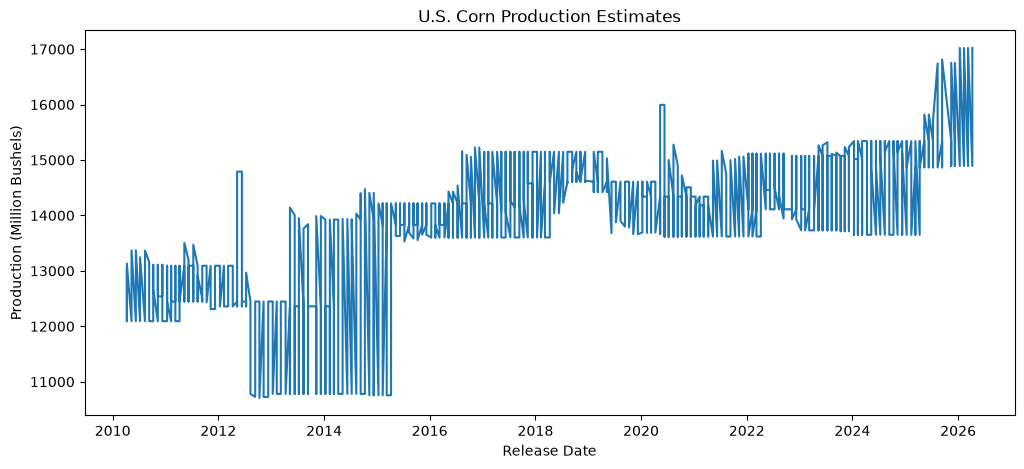

In [78]:
plt.figure(figsize=(12,5))

plt.plot(
    corn_prod["ReleaseDate"],
    corn_prod["Value"]
)

plt.title("U.S. Corn Production Estimates")
plt.xlabel("Release Date")
plt.ylabel("Production (Million Bushels)")
plt.show()

How does the USDA revise estimates within a marketing year?

In [79]:
my = corn_prod[
    corn_prod["MarketYear"] == "2022/23"
].sort_values("ReleaseDate")

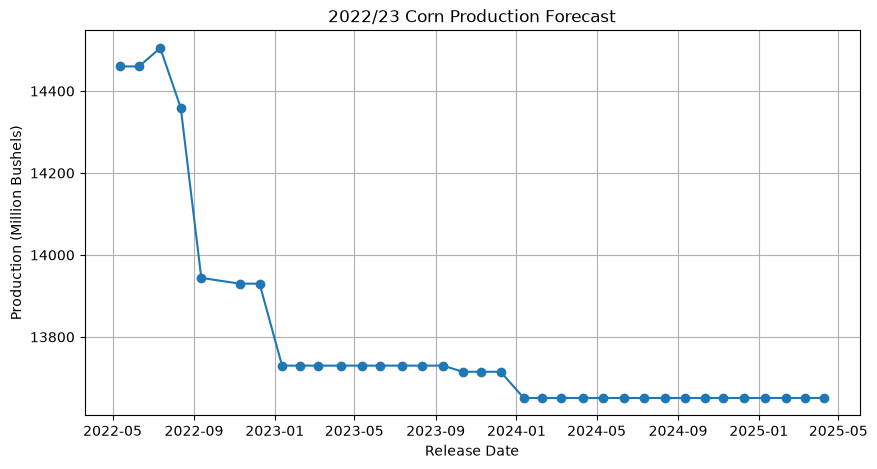

In [80]:
plt.figure(figsize=(10,5))

plt.plot(
    my["ReleaseDate"],
    my["Value"],
    marker="o"
)

plt.title("2022/23 Corn Production Forecast")
plt.xlabel("Release Date")
plt.ylabel("Production (Million Bushels)")
plt.grid(True)

plt.show()

This plot suggests that each market year is a sequence of revisions that overlaps into the following market year, not just one observation. That is why there is so much noise in the time series. This suggests that sequential revisions are made to production estimates by the USDA, converging toward the actual value as the market year progresses.

How many reports are there for each market year?

In [81]:
corn_prod.groupby("MarketYear").size()

MarketYear
2007/08     1
2008/09    13
2009/10    25
2010/11    36
2011/12    35
2012/13    35
2013/14    35
2014/15    36
2015/16    36
2016/17    35
2017/18    35
2018/19    35
2019/20    36
2020/21    35
2021/22    35
2022/23    35
2023/24    35
2024/25    23
2025/26    11
dtype: int64

In [82]:
my[["ReleaseDate", "Value"]]

,ReleaseDate,Value
WasdeNumber,,
624,2022-05-12,14460.0
625,2022-06-10,14460.0
626,2022-07-12,14505.0
627,2022-08-12,14359.0
628,2022-09-12,13944.0
630,2022-11-09,13930.0
631,2022-12-09,13930.0
632,2023-01-12,13730.0
633,2023-02-08,13730.0


Observation: Each market year remains in subsequent WASDE reports after the production estimate has stabilized. As a result, older market years contain repeated final estimates. This should be considered during model development because these repeated values are not new information.

Why does the estimate stop changing?

In [83]:
corn_prod.groupby("MarketYear")["Value"].nunique()

MarketYear
2007/08     1
2008/09     1
2009/10     3
2010/11     7
2011/12     9
2012/13     8
2013/14     8
2014/15     7
2015/16     8
2016/17     7
2017/18     8
2018/19     8
2019/20    11
2020/21     8
2021/22     9
2022/23     8
2023/24     8
2024/25     8
2025/26     6
Name: Value, dtype: int64

This suggests that only the first handful of reports actually revise the estimates

Overlay of several marketing years to ocmpare how different crop years evolved

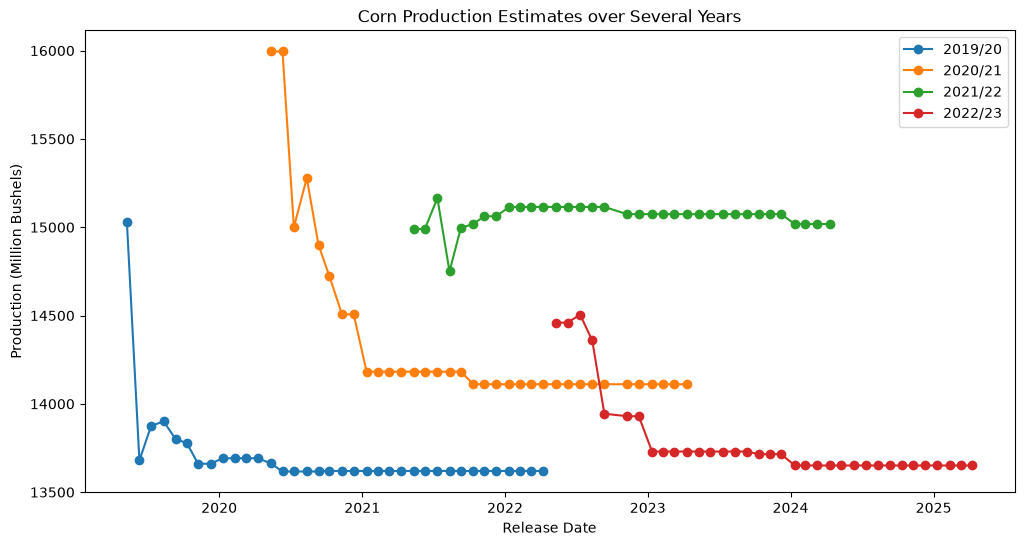

In [84]:
years = ["2019/20", "2020/21", "2021/22", "2022/23"]

plt.figure(figsize=(12,6))

for year in years:
    temp = corn_prod[
        corn_prod["MarketYear"] == year
    ].sort_values("ReleaseDate")

    plt.plot(
        temp["ReleaseDate"],
        temp["Value"],
        marker="o",
        label=year
    )
plt.title("Corn Production Estimates over Several Years")
plt.xlabel("Release Date")
plt.ylabel("Production (Million Bushels)")
plt.legend()
plt.show()

Each market year is updated monthly through successive WASDE reports. Production estimates are revised as new information becomes available and eventually stabilize once the crop year is complete. After stabilization, the USDA continues reporting the final estimate in later WASDE releases. Therefore, each market year contains both active forecast revisions and repeated finalized values.

# **Repeatable EDA pipeline function**

In [85]:
def run_commodity_attribute_eda(df, commodity, attribute, report_title, market_years=None):

    # -----------------------------
    # 1. Filter data
    # -----------------------------
    data = df[
        (df["Commodity"] == commodity) &
        (df["Attribute"] == attribute) &
        (df["ReportTitle"] == report_title)
    ].copy()

    data = data.sort_values("ReleaseDate")

    print("=" * 70)
    print(f"{commodity} - {attribute}")
    print("=" * 70)

    # -----------------------------
    # 2. Basic structure
    # -----------------------------
    print("\nShape:")
    print(data.shape)

    print("\nFirst rows:")
    display(data.head())

    print("\nInfo:")
    data.info()

    print("\nFull describe:")
    display(data.describe(include="all"))

    # -----------------------------
    # 3. Key date/value checks
    # -----------------------------
    print("\nReleaseDate, MarketYear, Value - first 10:")
    display(data[["ReleaseDate", "MarketYear", "Value"]].head(10))

    print("\nReleaseDate, MarketYear, Value - last 10:")
    display(data[["ReleaseDate", "MarketYear", "Value"]].tail(10))

    # -----------------------------
    # 4. Missing values
    # -----------------------------
    print("\nMissing values:")
    display(data.isna().sum())

    # -----------------------------
    # 5. Summary statistics
    # -----------------------------
    print("\nValue summary statistics:")
    display(data["Value"].describe())

    print("\nMedian value:")
    print(data["Value"].median())

    # -----------------------------
    # 6. Histogram
    # -----------------------------
    plt.figure(figsize=(8, 5))
    plt.hist(data["Value"], bins=25)
    plt.title(f"Distribution of {commodity} {attribute}")
    plt.xlabel(attribute)
    plt.ylabel("Frequency")
    plt.show()

    # -----------------------------
    # 7. Boxplot
    # -----------------------------
    plt.figure(figsize=(4, 6))
    plt.boxplot(data["Value"].dropna())
    plt.title(f"{commodity} {attribute}")
    plt.ylabel(f"{attribute} ({data['Unit'].iloc[0]})")
    plt.show()

    # -----------------------------
    # 8. Full time series
    # -----------------------------
    plt.figure(figsize=(12, 5))

    plt.plot(
        data["ReleaseDate"],
        data["Value"]
    )

    plt.title(f"U.S. {commodity} {attribute} Estimates")
    plt.xlabel("Release Date")
    plt.ylabel(f"{attribute} ({data['Unit'].iloc[0]})")
    plt.show()

    # -----------------------------
    # 9. Market year comparison plot
    # -----------------------------
    if market_years is not None:
        plt.figure(figsize=(12, 6))

        for year in market_years:
            temp = data[
                data["MarketYear"] == year
            ].sort_values("ReleaseDate")

            plt.plot(
                temp["ReleaseDate"],
                temp["Value"],
                marker="o",
                label=year
            )

        plt.title(f"{commodity} {attribute} Estimates over Several Years")
        plt.xlabel("Release Date")
        plt.ylabel(f"{attribute} ({data['Unit'].iloc[0]})")
        plt.legend()
        plt.show()

    return data

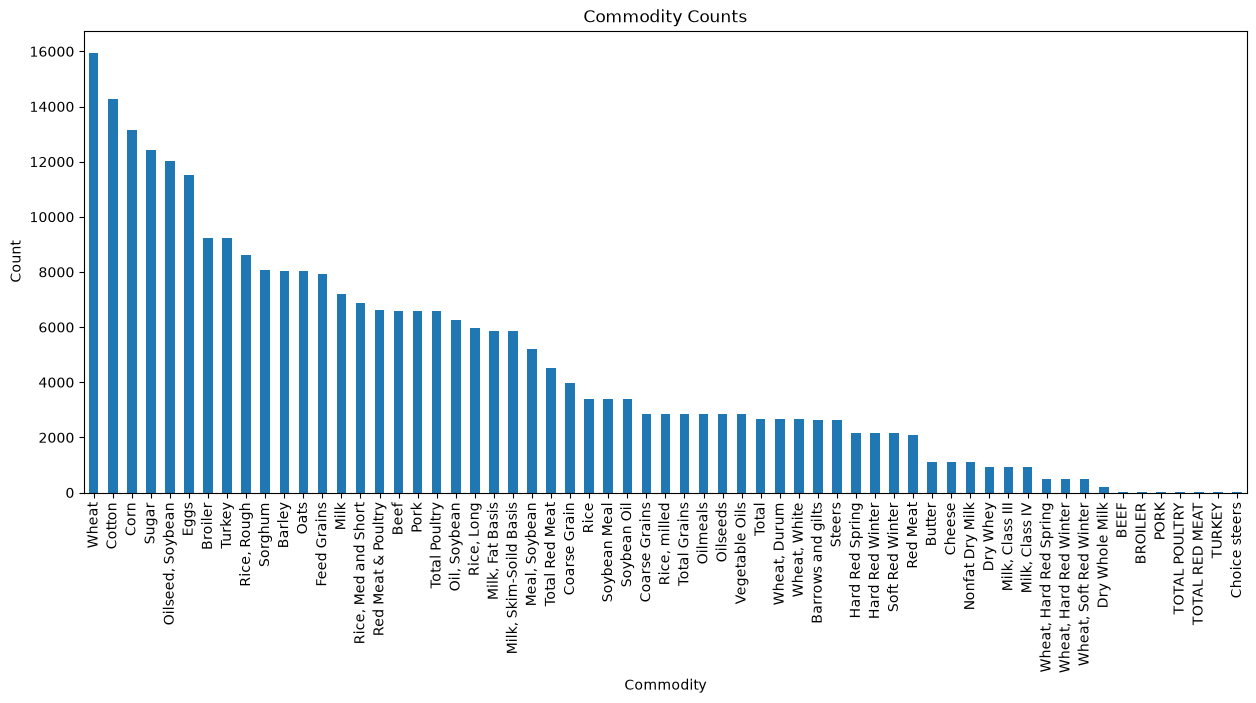

In [86]:
# plot value counts for all commodities sized correctly
plt.figure(figsize=(15,6))
plt.title("Commodity Counts")
plt.xlabel("Commodity")
plt.ylabel("Count")
df_us["Commodity"].value_counts().plot(kind="bar")
plt.show()

Open Market Commodities to prioritize:

- Corn ✅
- Sugar ✅
- Soybean ✅
- Soybean Meal ✅
- Soybean Oil ✅
- Wheat ✅
- Hard Red Winter ✅
- Hard Red Spring ✅
- Cotton ✅
- Rice, Rough ✅
- Oats ✅
- Steers
- Barrows and gilts
- Dry Whey
- Cheese
- Butter
- Milk

In [87]:
# Print all report titles
df_us["ReportTitle"].unique()

<StringArray>
[                                  'U.S. Cotton Supply and Use',
                                            'U.S. Dairy Prices',
                                      'U.S. Egg Supply and Use',
                      'U.S. Feed Grain and Corn Supply and Use',
                                    'U.S. Meats Supply and Use',
                                     'U.S. Milk Supply and Use',
                     'U.S. Quarterly Animal Product Production',
                    'U.S. Quarterly Prices for Animal Products',
                                     'U.S. Rice Supply and Use',
                'U.S. Sorghum, Barley, and Oats Supply and Use',
 'U.S. Soybeans and Products Supply and Use (Domestic Measure)',
                                    'U.S. Sugar Supply and Use',
                          'U.S. Wheat by Class: Supply and Use',
                                    'U.S. Wheat Supply and Use',
                      'World and U.S Supply and Use for Grains',
           

Normalizing hrs and hrw

In [88]:
df_us["Commodity"] = df_us["Commodity"].replace({
    "Wheat, Hard Red Spring": "Hard Red Spring"
})

In [89]:
print(df_us[df_us["ReportTitle"].str.contains("Wheat", case=False, na=False)]["ReportTitle"].unique())

<StringArray>
['U.S. Wheat by Class: Supply and Use',           'U.S. Wheat Supply and Use',
          'World Wheat Supply and Use']
Length: 3, dtype: str


In [90]:
print(df_us[df_us["Commodity"].str.contains("Hard Red Spring", case=False, na=False)]["Commodity"].unique())

<StringArray>
['Hard Red Spring']
Length: 1, dtype: str


To find corresponding report title

In [91]:
print(
    df_us[df_us["Commodity"].str.contains("Sugar", case=False, na=False)]
    .groupby(["Commodity", "ReportTitle"])["ReleaseDate"]
    .max()
)

Commodity  ReportTitle              
Sugar      U.S. Sugar Supply and Use   2026-04-09
Name: ReleaseDate, dtype: datetime64[us]


Running EDA Function

Sugar - Production

Shape:
(567, 15)

First rows:


,ReportDate,ReportTitle,Attribute,ReliabilityProjection,Commodity,Region,MarketYear,ProjEstFlag,AnnualQuarterFlag,Value,Unit,ReleaseDate,ReleaseTime,ForecastYear,ForecastMonth
WasdeNumber,,,,,,,,,,,,,,,
481,April 2010,U.S. Sugar Supply and Use,Production,NaN,Sugar,United States,2007/08,NaN,Annual,8152.0,"1000 Short Tons, Raw Value",2010-04-09,08:30:00.0000000,2010,4
481,April 2010,U.S. Sugar Supply and Use,Production,NaN,Sugar,United States,2008/09,Est.,Annual,7532.0,"1000 Short Tons, Raw Value",2010-04-09,08:30:00.0000000,2010,4
481,April 2010,U.S. Sugar Supply and Use,Production,NaN,Sugar,United States,2009/10,Proj.,Annual,7907.0,"1000 Short Tons, Raw Value",2010-04-09,08:30:00.0000000,2010,4
482,May 2010,U.S. Sugar Supply and Use,Production,NaN,Sugar,United States,2008/09,NaN,Annual,7532.0,"1000 Short Tons, Raw Value",2010-05-11,08:30:00.0000000,2010,5
482,May 2010,U.S. Sugar Supply and Use,Production,NaN,Sugar,United States,2009/10,Est.,Annual,7847.0,"1000 Short Tons, Raw Value",2010-05-11,08:30:00.0000000,2010,5



Info:
<class 'pandas.DataFrame'>
Index: 567 entries, 481 to 670
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ReportDate             567 non-null    str           
 1   ReportTitle            567 non-null    str           
 2   Attribute              567 non-null    str           
 3   ReliabilityProjection  0 non-null      float64       
 4   Commodity              567 non-null    str           
 5   Region                 567 non-null    str           
 6   MarketYear             567 non-null    str           
 7   ProjEstFlag            378 non-null    str           
 8   AnnualQuarterFlag      567 non-null    str           
 9   Value                  567 non-null    float64       
 10  Unit                   567 non-null    str           
 11  ReleaseDate            567 non-null    datetime64[us]
 12  ReleaseTime            567 non-null    str           
 13  ForecastYear

,ReportDate,ReportTitle,Attribute,ReliabilityProjection,Commodity,Region,MarketYear,ProjEstFlag,AnnualQuarterFlag,Value,Unit,ReleaseDate,ReleaseTime,ForecastYear,ForecastMonth
count,567,567,567,0.0,567,567,567,378,567,567.000000,567,567,567,567.000000,567.000000
unique,189,1,1,NaN,1,1,19,2,1,NaN,1,NaN,3,NaN,NaN
top,April 2010,U.S. Sugar Supply and Use,Production,NaN,Sugar,United States,2010/11,Est.,Annual,NaN,"1000 Short Tons, Raw Value",NaN,12:00:00.0000000,NaN,NaN
freq,3,567,567,NaN,567,567,36,189,567,NaN,567,NaN,453,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8787.291005,NaN,2018-03-25 22:20:57.142857,NaN,2017.751323,6.460317
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7532.000000,NaN,2010-04-09 00:00:00,NaN,2010.000000,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8462.000000,NaN,2014-04-09 00:00:00,NaN,2014.000000,4.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8980.000000,NaN,2018-03-08 00:00:00,NaN,2018.000000,6.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9233.000000,NaN,2022-03-09 00:00:00,NaN,2022.000000,9.000000
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9514.000000,NaN,2026-04-09 00:00:00,NaN,2026.000000,12.000000



ReleaseDate, MarketYear, Value - first 10:


...


Missing values:


ReportDate                 0
ReportTitle                0
Attribute                  0
ReliabilityProjection    567
Commodity                  0
Region                     0
MarketYear                 0
ProjEstFlag              189
AnnualQuarterFlag          0
Value                      0
Unit                       0
ReleaseDate                0
ReleaseTime                0
ForecastYear               0
ForecastMonth              0
dtype: int64


Value summary statistics:


count     567.000000
mean     8787.291005
std       506.946870
min      7532.000000
25%      8462.000000
50%      8980.000000
75%      9233.000000
max      9514.000000
Name: Value, dtype: float64


Median value:
8980.0


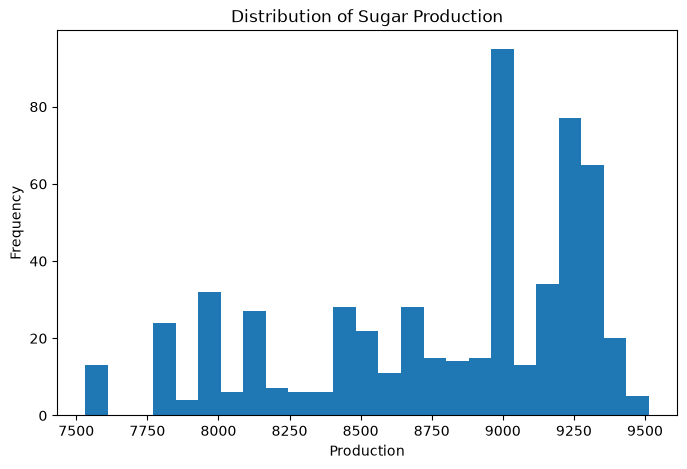

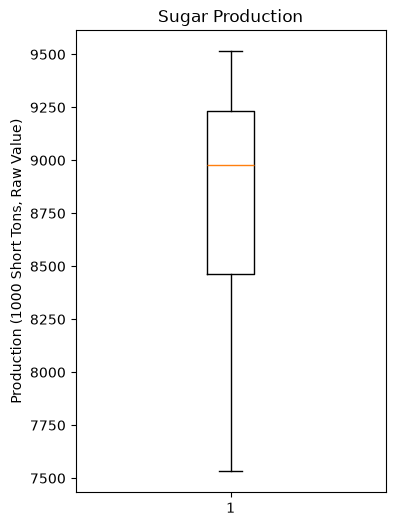

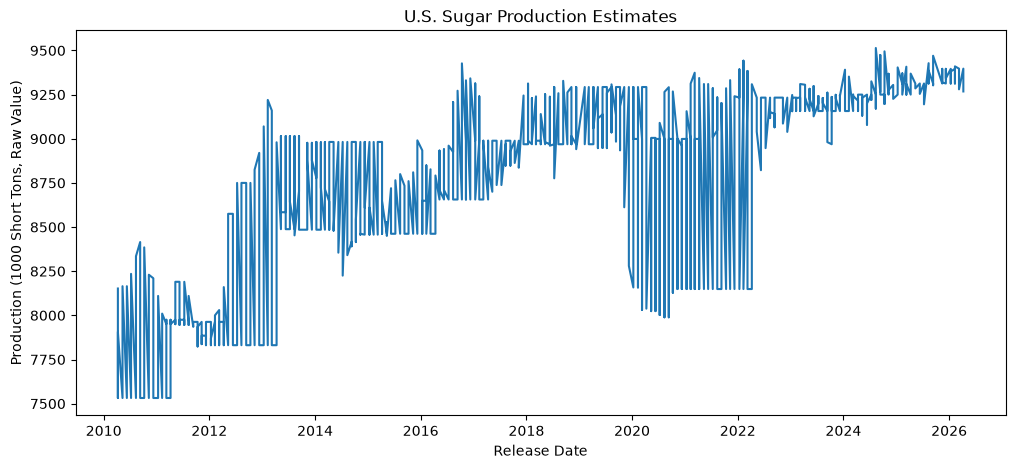

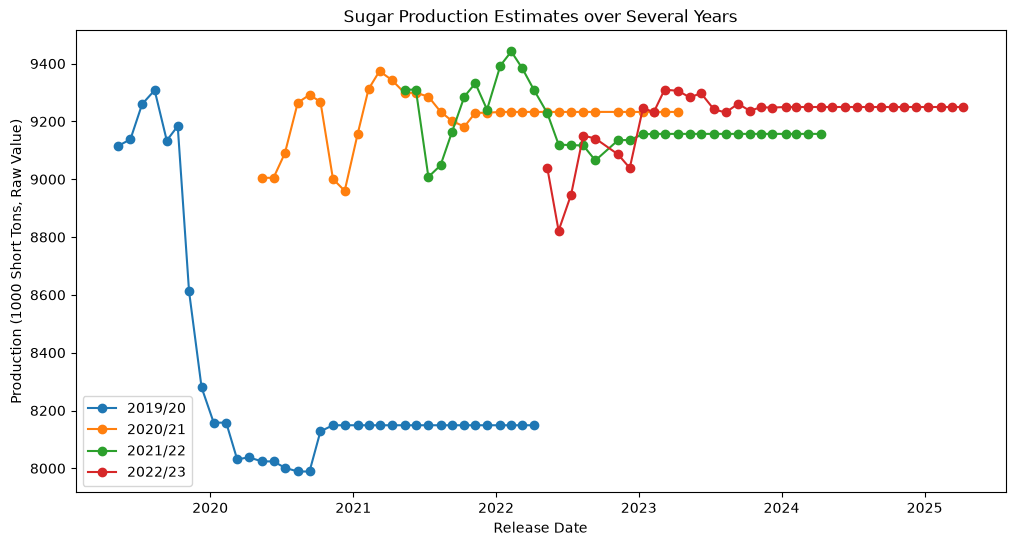

In [92]:
sugar_prod = run_commodity_attribute_eda(
    df=df_us,
    commodity="Sugar",
    attribute="Production",
    report_title="U.S. Sugar Supply and Use",
    market_years=["2019/20", "2020/21", "2021/22", "2022/23"]
)

# **Export the Data**

In [93]:
# open market commodities
corn = df_us[
    df_us["ReportTitle"] == "U.S. Feed Grain and Corn Supply and Use"
]
soybeans = df_us[
    df_us["ReportTitle"] == "U.S. Soybeans and Products Supply and Use (Domestic Measure)"
]
cotton = df_us[
    df_us["ReportTitle"] == "U.S. Cotton Supply and Use"
]
wheat = df_us[
    df_us["ReportTitle"] == "U.S. Wheat Supply and Use"
]
rice = df_us[
    df_us["ReportTitle"] == "U.S. Rice Supply and Use"
]
oats = df_us[
    df_us["ReportTitle"] == "U.S. Sorghum, Barley, and Oats Supply and Use"
]
hrw = df_us[
    df_us["ReportTitle"] == "U.S. Wheat by Class: Supply and Use"
]
sugar = df_us[
    df_us["ReportTitle"] == "U.S. Sugar Supply and Use"
]

In [94]:
sugar_prod = sugar[
    (sugar["Commodity"] == "Sugar") &
    (sugar["Attribute"] == "Production")
].copy()

In [95]:
sugar_prod.head()

,ReportDate,ReportTitle,Attribute,ReliabilityProjection,Commodity,Region,MarketYear,ProjEstFlag,AnnualQuarterFlag,Value,Unit,ReleaseDate,ReleaseTime,ForecastYear,ForecastMonth
WasdeNumber,,,,,,,,,,,,,,,
481,April 2010,U.S. Sugar Supply and Use,Production,NaN,Sugar,United States,2007/08,NaN,Annual,8152.0,"1000 Short Tons, Raw Value",2010-04-09,08:30:00.0000000,2010,4
481,April 2010,U.S. Sugar Supply and Use,Production,NaN,Sugar,United States,2008/09,Est.,Annual,7532.0,"1000 Short Tons, Raw Value",2010-04-09,08:30:00.0000000,2010,4
481,April 2010,U.S. Sugar Supply and Use,Production,NaN,Sugar,United States,2009/10,Proj.,Annual,7907.0,"1000 Short Tons, Raw Value",2010-04-09,08:30:00.0000000,2010,4
482,May 2010,U.S. Sugar Supply and Use,Production,NaN,Sugar,United States,2008/09,NaN,Annual,7532.0,"1000 Short Tons, Raw Value",2010-05-11,08:30:00.0000000,2010,5
482,May 2010,U.S. Sugar Supply and Use,Production,NaN,Sugar,United States,2009/10,Est.,Annual,7847.0,"1000 Short Tons, Raw Value",2010-05-11,08:30:00.0000000,2010,5


In [ ]:
# export commodity data subsets to csv for modeling
output_path = Path("../../data/processed/commodity_prod/sugar_prod.csv")
sugar_prod.to_csv(output_path, index=False)

# **FORECASTING**


What are we trying to forecast?

- Predict the next monthly USDA revision.

- Predict the final production estimate for a market year.

- Predict the production reported in future WASDE releases